# Hybrid GBRT Fusion — The Headline Contribution

This notebook stacks the seven CF baselines (SVD, item-CF, user-CF, KNN, content-based, NeuMF, graph PPR) through a **gradient-boosted decision tree** that learns where each baseline is most reliable. Each base model's predicted rating becomes a feature; side features (user activity, item popularity, item age, content similarity) are added; the GBRT learns a non-linear fusion that outperforms every individual baseline.

## Methodology

**Out-of-fold (OOF) stacking.** Training a stacking meta-learner naively on the same data that produced the base predictions creates leakage — the base models have overfit to those points, so their in-sample predictions are unrealistically accurate, and the meta-learner learns to trust them too much. The standard fix is K-fold cross-prediction:

1. Split the training data into K folds.
2. For each fold `k`: train each base model on the other K − 1 folds, predict on fold `k` to get out-of-fold predictions.
3. Concatenate the OOF predictions over all K — every (user, item) in the training set now has predictions from base models that did **not** see it during training.
4. Train the GBRT on those OOF predictions (+ side features) against the true ratings.
5. For test-set inference: refit each base model on the full training data, predict on the test set, feed into the trained GBRT.

We use K = 3 (matching the rest of this project's evaluation setup). The base-model OOF predictions are the GBRT's strongest features; if a particular base is reliable in a region of the feature space, the GBRT learns to put high weight on it there.

## Architectural reference

The GBRT-fusion pattern is adapted from Volokhin, Pera, Tintarev — *"You Sound Like Someone Who Watches Drama Movies: Towards Predicting Movie Preferences from Conversational Interactions"* (NAACL 2021). That paper fuses a CF prediction with conversational sentiment signals and metadata embeddings via GBRT; we apply the same fusion architecture to a different set of inputs (seven CF baselines on MovieLens rather than CF + conversational features). Their re-implementation in this repository at `movie-rec-conversational-data-main/` (Mehta, Parikh, Gaglani) is the direct code reference.

## Inputs / outputs

- Reads `splits/{train,val,test}.csv` and `movies_with_tags.csv` from Google Drive.
- Reads `predictions/neural_cf.csv` (re-training NeuMF inside this notebook for OOF would require a GPU; we load saved test predictions and re-run NeuMF only with reduced epochs for OOF).
- Writes `predictions/hybrid_gbrt.csv` — final fused test predictions.
- Writes `results/comparison_table.csv` — every method's metrics side by side.
- Writes `results/feature_importance.png` — GBRT feature importance for the discussion.

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [2]:
# scikit-surprise 1.1.4 was compiled against NumPy 1.x. Colab's default is NumPy 2.x,
# which is binary-incompatible. Install numpy<2 first, then force a kernel restart so
# Python re-loads with the downgraded numpy. After the restart, re-run this cell —
# the pip install will be a no-op and the kernel-restart check will pass.
!pip install -q "numpy<2" scikit-surprise==1.1.4 sentence-transformers==2.7.0 lightgbm==4.3.0

import numpy as np
if np.__version__.startswith('2.'):
    print('Downgrading numpy required a kernel restart. Restarting now...')
    print('After restart: re-mount Drive (re-run the drive.mount cell) and re-run this cell.')
    import os
    os.kill(os.getpid(), 9)
else:
    print(f'NumPy {np.__version__} OK — scikit-surprise + sentence-transformers + lightgbm ready')

NumPy 1.26.4 OK — scikit-surprise + sentence-transformers + lightgbm ready


In [3]:
import os, random, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse import csr_matrix, coo_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import KFold
import lightgbm as lgb

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

ARTIFACT_DIR    = Path('/content/gdrive/MyDrive/recsys_artifacts')
SPLITS_DIR      = ARTIFACT_DIR / 'splits'
PREDICTIONS_DIR = ARTIFACT_DIR / 'predictions'
RESULTS_DIR     = ARTIFACT_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.append(str(ARTIFACT_DIR))
from recsys_metrics import build_candidate_lists, evaluate_model, paired_wilcoxon

In [4]:
train = pd.read_csv(SPLITS_DIR / 'train.csv')
val   = pd.read_csv(SPLITS_DIR / 'val.csv')
test  = pd.read_csv(SPLITS_DIR / 'test.csv')
trainval = pd.concat([train, val], ignore_index=True)
print(f'train: {len(train):,}  val: {len(val):,}  test: {len(test):,}  trainval: {len(trainval):,}')

GLOBAL_MEAN = float(trainval['rating'].mean())

train: 99,616  val: 610  test: 610  trainval: 100,226


## Base-model wrappers

Each base model exposes the same minimal interface:
- `fit(train_df)` — train on a DataFrame with columns `userId, movieId, rating`.
- `predict(df)` — return per-row predicted ratings for a DataFrame with `userId, movieId`.

The implementations are condensed versions of the standalone baseline notebooks. They produce the same predictions modulo numerical-precision differences; the standalone notebooks remain authoritative for documentation and per-method analysis.

In [5]:
from surprise import SVD, Dataset, Reader

class SVDModel:
    name = 'svd'
    def fit(self, train_df):
        reader = Reader(rating_scale=(0.5, 5.0))
        data = Dataset.load_from_df(train_df[['userId', 'movieId', 'rating']], reader)
        self.algo = SVD(n_factors=100, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=SEED)
        self.algo.fit(data.build_full_trainset())
        return self
    def predict(self, df):
        return np.array([self.algo.predict(u, m).est for u, m in zip(df['userId'], df['movieId'])])

In [6]:
from surprise import KNNBaseline

class KNNItemModel:
    name = 'knn_item'
    def fit(self, train_df):
        reader = Reader(rating_scale=(0.5, 5.0))
        data = Dataset.load_from_df(train_df[['userId', 'movieId', 'rating']], reader)
        self.algo = KNNBaseline(k=20, sim_options={'name': 'pearson_baseline', 'user_based': False}, verbose=False)
        self.algo.fit(data.build_full_trainset())
        return self
    def predict(self, df):
        return np.array([self.algo.predict(u, m).est for u, m in zip(df['userId'], df['movieId'])])

class KNNUserModel:
    name = 'knn_user'
    def fit(self, train_df):
        reader = Reader(rating_scale=(0.5, 5.0))
        data = Dataset.load_from_df(train_df[['userId', 'movieId', 'rating']], reader)
        self.algo = KNNBaseline(k=20, sim_options={'name': 'pearson_baseline', 'user_based': True}, verbose=False)
        self.algo.fit(data.build_full_trainset())
        return self
    def predict(self, df):
        return np.array([self.algo.predict(u, m).est for u, m in zip(df['userId'], df['movieId'])])

In [7]:
def _build_user_item_sparse(train_df, scale=(0.5, 5.0)):
    users  = sorted(train_df['userId'].unique())
    movies = sorted(train_df['movieId'].unique())
    u2i = {u: i for i, u in enumerate(users)}
    m2i = {m: i for i, m in enumerate(movies)}
    rows = train_df['userId'].map(u2i).to_numpy()
    cols = train_df['movieId'].map(m2i).to_numpy()
    vals = train_df['rating'].to_numpy(dtype=np.float32)
    R = csr_matrix((vals, (rows, cols)), shape=(len(users), len(movies)))
    return R, u2i, m2i

class UserCFModel:
    name = 'user_cf'
    def fit(self, train_df):
        self.R, self.u2i, self.m2i = _build_user_item_sparse(train_df)
        self.user_means = np.divide(
            np.asarray(self.R.sum(axis=1)).flatten(),
            np.asarray((self.R != 0).sum(axis=1)).flatten(),
            out=np.full(self.R.shape[0], GLOBAL_MEAN),
            where=np.asarray((self.R != 0).sum(axis=1)).flatten() > 0,
        )
        R_centered = self.R.copy().astype(np.float32)
        for u in range(R_centered.shape[0]):
            s, e = R_centered.indptr[u], R_centered.indptr[u + 1]
            R_centered.data[s:e] -= self.user_means[u]
        self.user_sim = cosine_similarity(R_centered, dense_output=True)
        np.fill_diagonal(self.user_sim, 0.0)
        return self
    def _predict_one(self, u, m, top_k=30):
        if u not in self.u2i: return GLOBAL_MEAN
        ui = self.u2i[u]
        if m not in self.m2i: return self.user_means[ui]
        mi = self.m2i[m]
        item_col = self.R.getcol(mi).toarray().flatten()
        raters = np.where(item_col > 0)[0]
        if len(raters) == 0: return self.user_means[ui]
        sims = self.user_sim[ui, raters]
        top = np.argsort(-sims)[:top_k]
        s, r = sims[top], item_col[raters[top]]
        if np.abs(s).sum() < 1e-9: return self.user_means[ui]
        return float(np.clip(self.user_means[ui] + (s * (r - self.user_means[raters[top]])).sum() / np.abs(s).sum(), 0.5, 5.0))
    def predict(self, df):
        return np.array([self._predict_one(u, m) for u, m in zip(df['userId'], df['movieId'])])

class ItemCFModel:
    name = 'item_cf'
    def fit(self, train_df):
        self.R, self.u2i, self.m2i = _build_user_item_sparse(train_df)
        self.user_means = np.divide(
            np.asarray(self.R.sum(axis=1)).flatten(),
            np.asarray((self.R != 0).sum(axis=1)).flatten(),
            out=np.full(self.R.shape[0], GLOBAL_MEAN),
            where=np.asarray((self.R != 0).sum(axis=1)).flatten() > 0,
        )
        R_iu = self.R.T.tocsr()
        self.item_means = np.divide(
            np.asarray(R_iu.sum(axis=1)).flatten(),
            np.asarray((R_iu != 0).sum(axis=1)).flatten(),
            out=np.full(R_iu.shape[0], GLOBAL_MEAN),
            where=np.asarray((R_iu != 0).sum(axis=1)).flatten() > 0,
        )
        # Adjusted cosine: subtract user mean from each rating before computing item-item cosine.
        R_iu_centered = R_iu.copy().astype(np.float32).tocsc()
        for c in range(R_iu_centered.shape[1]):
            s, e = R_iu_centered.indptr[c], R_iu_centered.indptr[c + 1]
            R_iu_centered.data[s:e] -= self.user_means[c]
        self.item_sim = cosine_similarity(R_iu_centered.tocsr(), dense_output=True)
        np.fill_diagonal(self.item_sim, 0.0)
        return self
    def _predict_one(self, u, m, top_k=30):
        if m not in self.m2i: return GLOBAL_MEAN
        mi = self.m2i[m]
        if u not in self.u2i: return self.item_means[mi]
        ui = self.u2i[u]
        user_row = self.R.getrow(ui).toarray().flatten()
        rated = np.where(user_row > 0)[0]
        if len(rated) == 0: return self.item_means[mi]
        sims = self.item_sim[mi, rated]
        top = np.argsort(-sims)[:top_k]
        s, r = sims[top], user_row[rated[top]]
        if np.abs(s).sum() < 1e-9: return self.item_means[mi]
        return float(np.clip(self.item_means[mi] + (s * (r - self.item_means[rated[top]])).sum() / np.abs(s).sum(), 0.5, 5.0))
    def predict(self, df):
        return np.array([self._predict_one(u, m) for u, m in zip(df['userId'], df['movieId'])])

In [8]:
from sentence_transformers import SentenceTransformer

# Load the movie content embeddings once — they don't depend on the train split.
movies_meta = pd.read_csv(ARTIFACT_DIR / 'movies_with_tags.csv')[['movieId', 'content_text']]
movies_meta['content_text'] = movies_meta['content_text'].fillna('').astype(str)
sbert = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
MOVIE_EMB = np.asarray(sbert.encode(movies_meta['content_text'].tolist(), batch_size=64,
                                     show_progress_bar=True, normalize_embeddings=True), dtype=np.float32)
MOVIE_ROW = {mid: i for i, mid in enumerate(movies_meta['movieId'].values)}

class ContentModel:
    name = 'content'
    def fit(self, train_df):
        self.user_hist = (train_df.groupby('userId')
                                    .apply(lambda d: list(zip(d['movieId'], d['rating'])))
                                    .to_dict())
        return self
    def _predict_one(self, u, m, top_k=30):
        if m not in MOVIE_ROW or u not in self.user_hist: return GLOBAL_MEAN
        cand = MOVIE_EMB[MOVIE_ROW[m]]
        hist = self.user_hist[u]
        rows = np.array([MOVIE_ROW[mid] for mid, _ in hist if mid in MOVIE_ROW])
        ratings = np.array([r for mid, r in hist if mid in MOVIE_ROW], dtype=np.float32)
        if len(rows) == 0: return GLOBAL_MEAN
        sims = np.clip(MOVIE_EMB[rows] @ cand, 0, None)
        top = np.argsort(-sims)[:top_k]
        if sims[top].sum() < 1e-9: return float(ratings.mean())
        return float(np.clip((sims[top] * ratings[top]).sum() / sims[top].sum(), 0.5, 5.0))
    def predict(self, df):
        return np.array([self._predict_one(u, m) for u, m in zip(df['userId'], df['movieId'])])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/153 [00:00<?, ?it/s]

In [9]:
class GraphPPRModel:
    name = 'graph'
    def fit(self, train_df, alpha=0.85, max_iter=50, tol=1e-6):
        users  = sorted(train_df['userId'].unique())
        movies = sorted(train_df['movieId'].unique())
        self.u2i = {u: i for i, u in enumerate(users)}
        self.m2i = {m: i for i, m in enumerate(movies)}
        self.n_users, self.n_movies = len(users), len(movies)
        N = self.n_users + self.n_movies
        u_idx = train_df['userId'].map(self.u2i).to_numpy()
        m_idx = train_df['movieId'].map(self.m2i).to_numpy() + self.n_users
        w = train_df['rating'].to_numpy(dtype=np.float32)
        rows = np.concatenate([u_idx, m_idx]); cols = np.concatenate([m_idx, u_idx])
        data = np.concatenate([w, w])
        A = coo_matrix((data, (rows, cols)), shape=(N, N)).tocsr()
        rs = np.asarray(A.sum(axis=1)).flatten()
        rs_safe = np.where(rs > 0, rs, 1.0)
        D_inv = csr_matrix((1.0 / rs_safe, (np.arange(N), np.arange(N))), shape=(N, N))
        M_T = (D_inv @ A).T.tocsr()
        self.user_means = train_df.groupby('userId')['rating'].mean().to_dict()
        self.alpha, self.max_iter, self.tol = alpha, max_iter, tol
        self.M_T = M_T; self.N = N
        self._cache = {}
        return self
    def _ppr(self, user_id):
        if user_id in self._cache: return self._cache[user_id]
        v = np.zeros(self.N, dtype=np.float32); v[self.u2i[user_id]] = 1.0
        p = v.copy()
        for _ in range(self.max_iter):
            p_next = self.alpha * (self.M_T @ p) + (1 - self.alpha) * v
            if np.abs(p_next - p).sum() < self.tol: p = p_next; break
            p = p_next
        self._cache[user_id] = p
        return p
    def _predict_one(self, u, m):
        if u not in self.u2i or m not in self.m2i: return GLOBAL_MEAN
        p = self._ppr(u)
        movie_block = p[self.n_users:]
        s = float(p[self.m2i[m] + self.n_users])
        mu, sd = movie_block.mean(), movie_block.std()
        z = (s - mu) / (sd + 1e-9)
        return float(np.clip(self.user_means.get(u, GLOBAL_MEAN) + 0.5 * np.tanh(z), 0.5, 5.0))
    def predict(self, df):
        return np.array([self._predict_one(u, m) for u, m in zip(df['userId'], df['movieId'])])

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

class NeuMFModel:
    name = 'neumf'
    def __init__(self, epochs=10):
        self.epochs = epochs
    def fit(self, train_df):
        tf.random.set_seed(SEED)
        self.users = sorted(train_df['userId'].unique())
        self.movies = sorted(train_df['movieId'].unique())
        self.u2i = {u: i for i, u in enumerate(self.users)}
        self.m2i = {m: i for i, m in enumerate(self.movies)}
        n_u, n_m = len(self.users), len(self.movies)
        u_in = keras.Input(shape=(), dtype='int32'); m_in = keras.Input(shape=(), dtype='int32')
        mf_u = layers.Embedding(n_u, 16, embeddings_initializer='he_normal')(u_in)
        mf_m = layers.Embedding(n_m, 16, embeddings_initializer='he_normal')(m_in)
        gmf = layers.Multiply()([mf_u, mf_m])
        mlp_u = layers.Embedding(n_u, 32, embeddings_initializer='he_normal')(u_in)
        mlp_m = layers.Embedding(n_m, 32, embeddings_initializer='he_normal')(m_in)
        x = layers.Concatenate()([mlp_u, mlp_m])
        for u in [32, 16, 8]: x = layers.Dense(u, activation='relu')(x)
        out = layers.Dense(1, activation='sigmoid')(layers.Concatenate()([gmf, x]))
        self.model = keras.Model([u_in, m_in], out)
        self.model.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
        u_arr = train_df['userId'].map(self.u2i).to_numpy(np.int32)
        m_arr = train_df['movieId'].map(self.m2i).to_numpy(np.int32)
        r_arr = ((train_df['rating'].to_numpy(np.float32) - 0.5) / 4.5)
        self.model.fit([u_arr, m_arr], r_arr, batch_size=256, epochs=self.epochs, verbose=0)
        return self
    def predict(self, df):
        u_idx = df['userId'].map(lambda u: self.u2i.get(u, -1)).to_numpy()
        m_idx = df['movieId'].map(lambda m: self.m2i.get(m, -1)).to_numpy()
        valid = (u_idx >= 0) & (m_idx >= 0)
        out = np.full(len(df), GLOBAL_MEAN, dtype=np.float32)
        if valid.any():
            sig = self.model.predict([u_idx[valid].astype(np.int32), m_idx[valid].astype(np.int32)],
                                      batch_size=1024, verbose=0).flatten()
            out[valid] = sig * 4.5 + 0.5
        return out

## Out-of-fold cross-prediction on `trainval`

For each base model and each of K = 3 folds:
- Fit on the other K − 1 folds.
- Predict on the held-out fold.
- Concatenate the per-fold predictions to get full OOF predictions for `trainval`.

The user-level temporal LOO structure is preserved across folds — we split rows from `trainval` uniformly, which keeps users in every fold (just with different subsets of their history). This is the right thing for stacking: the GBRT is trained on signals that mimic the test-time information state ("some of this user's history is known, some is not").

In [11]:
BASE_MODELS = [SVDModel, ItemCFModel, UserCFModel, KNNItemModel, KNNUserModel, ContentModel, GraphPPRModel, NeuMFModel]
MODEL_NAMES = [cls().name if not isinstance(cls, type) or cls is NeuMFModel else cls.name for cls in BASE_MODELS]
# NeuMF.name is a class attr, but instances also have it; just compute robustly:
def model_name(cls):
    return cls.name if isinstance(cls.name, str) else cls().name
MODEL_NAMES = [model_name(cls) for cls in BASE_MODELS]

kf = KFold(n_splits=3, shuffle=True, random_state=SEED)
oof_preds = pd.DataFrame({'userId': trainval['userId'].values,
                          'movieId': trainval['movieId'].values,
                          'rating':  trainval['rating'].values})
for name in MODEL_NAMES:
    oof_preds[f'{name}_pred'] = np.nan

trainval_idx = np.arange(len(trainval))
for fold_idx, (tr_idx, va_idx) in enumerate(kf.split(trainval_idx)):
    print(f'\n--- Fold {fold_idx + 1}/3 ---  train={len(tr_idx):,}  oof={len(va_idx):,}')
    df_tr = trainval.iloc[tr_idx].reset_index(drop=True)
    df_va = trainval.iloc[va_idx].reset_index(drop=True)
    for cls in BASE_MODELS:
        name = model_name(cls)
        t0 = time.time()
        model = cls(epochs=5) if cls is NeuMFModel else cls()
        model.fit(df_tr)
        preds = model.predict(df_va)
        oof_preds.loc[va_idx, f'{name}_pred'] = preds
        print(f'  {name:10s}  done in {time.time() - t0:5.1f}s  '
              f'(RMSE on fold = {np.sqrt(((preds - df_va["rating"].values) ** 2).mean()):.4f})')

print('\nOOF predictions sample:')
oof_preds.head()


--- Fold 1/3 ---  train=66,817  oof=33,409
  svd         done in   1.5s  (RMSE on fold = 0.8833)
  item_cf     done in   4.8s  (RMSE on fold = 0.8851)
  user_cf     done in   6.8s  (RMSE on fold = 0.8847)
  knn_item    done in   9.4s  (RMSE on fold = 0.8645)
  knn_user    done in   1.5s  (RMSE on fold = 0.8887)
  content     done in  17.7s  (RMSE on fold = 0.9088)
  graph       done in  11.3s  (RMSE on fold = 0.9578)
  neumf       done in  13.2s  (RMSE on fold = 0.9065)

--- Fold 2/3 ---  train=66,817  oof=33,409
  svd         done in   0.9s  (RMSE on fold = 0.8866)
  item_cf     done in   5.3s  (RMSE on fold = 0.8915)
  user_cf     done in   7.4s  (RMSE on fold = 0.8929)
  knn_item    done in  10.7s  (RMSE on fold = 0.8671)
  knn_user    done in   1.4s  (RMSE on fold = 0.8941)
  content     done in  17.4s  (RMSE on fold = 0.9124)
  graph       done in  11.5s  (RMSE on fold = 0.9541)
  neumf       done in   7.9s  (RMSE on fold = 0.9022)

--- Fold 3/3 ---  train=66,818  oof=33,408
  sv

,userId,movieId,rating,svd_pred,item_cf_pred,user_cf_pred,knn_item_pred,knn_user_pred,content_pred,graph_pred,neumf_pred
0,1,804,4.0,4.131868,3.599232,4.356017,3.911495,4.541876,4.195916,4.235471,4.116493
1,1,1210,5.0,4.892310,4.641291,5.000000,4.581886,5.000000,4.368218,4.846222,4.760400
2,1,2018,5.0,4.297165,4.307774,4.718481,4.194705,4.787783,4.527152,4.464348,4.230633
3,1,2628,4.0,3.732051,3.699577,4.089907,3.922515,4.156267,4.168511,4.831420,4.206224
4,1,2826,4.0,3.992967,3.777460,3.813987,3.747213,3.518098,4.355278,4.449517,3.615596


## Final base-model fit on `trainval`, predict on `test`

Now that we have OOF predictions for GBRT training, refit each base model on the full `trainval` and predict on the held-out `test`. These predictions become the GBRT's test-time features.

In [12]:
test_preds = test[['userId', 'movieId', 'rating']].copy()
fitted_models = {}
for cls in BASE_MODELS:
    name = model_name(cls)
    t0 = time.time()
    model = cls(epochs=10) if cls is NeuMFModel else cls()
    model.fit(trainval)
    test_preds[f'{name}_pred'] = model.predict(test)
    fitted_models[name] = model
    print(f'  {name:10s}  refit in {time.time() - t0:5.1f}s  '
          f'(test RMSE = {np.sqrt(((test_preds[f"{name}_pred"] - test["rating"]) ** 2).mean()):.4f})')

  svd         refit in   1.2s  (test RMSE = 0.9523)
  item_cf     refit in   1.0s  (test RMSE = 0.9815)
  user_cf     refit in   0.2s  (test RMSE = 0.9753)
  knn_item    refit in   7.1s  (test RMSE = 0.9691)
  knn_user    refit in   0.8s  (test RMSE = 0.9775)
  content     refit in   0.3s  (test RMSE = 0.9944)
  graph       refit in  11.2s  (test RMSE = 1.0300)
  neumf       refit in  16.1s  (test RMSE = 1.0323)


## Side features

Statistical priors and a content-similarity signal. These help the GBRT route around regions of the (user, item) space where the base models are unreliable — e.g., cold items where SVD has high variance.

Features:
- `user_mean_rating`, `user_rating_count` — user reliability priors.
- `item_mean_rating`, `item_rating_count`, `item_popularity_bin` — item popularity priors.
- `item_age_years` — release-recency signal extracted from the title `(YYYY)`.
- `user_movie_content_sim` — cosine similarity of the candidate's sentence embedding to the user's mean rated-movie embedding.

In [13]:
user_stats = trainval.groupby('userId')['rating'].agg(['mean', 'count']).rename(
    columns={'mean': 'user_mean_rating', 'count': 'user_rating_count'})
item_stats = trainval.groupby('movieId')['rating'].agg(['mean', 'count']).rename(
    columns={'mean': 'item_mean_rating', 'count': 'item_rating_count'})
item_stats['item_popularity_bin'] = pd.qcut(item_stats['item_rating_count'], q=5, labels=False, duplicates='drop')

# Item release year from title (e.g. "Toy Story (1995)")
movies_meta_full = pd.read_csv(ARTIFACT_DIR / 'movies_with_tags.csv')
year_re = movies_meta_full['title'].str.extract(r'\((\d{4})\)$')
movies_meta_full['year'] = pd.to_numeric(year_re[0], errors='coerce')
movies_meta_full['item_age_years'] = 2018 - movies_meta_full['year']  # ml-latest-small was released 09/2018
age_map = movies_meta_full.set_index('movieId')['item_age_years']

def attach_side_features(df):
    out = df.merge(user_stats, on='userId', how='left')
    out = out.merge(item_stats, on='movieId', how='left')
    out['item_age_years'] = out['movieId'].map(age_map)
    return out

oof_full  = attach_side_features(oof_preds)
test_full = attach_side_features(test_preds)

# Content similarity feature: mean of user's training-set movie embeddings dot candidate.
user_train_emb = {}
for uid, grp in trainval.groupby('userId'):
    rows = [MOVIE_ROW[m] for m in grp['movieId'] if m in MOVIE_ROW]
    if rows:
        user_train_emb[uid] = MOVIE_EMB[rows].mean(axis=0)

def content_sim(row):
    if row['userId'] not in user_train_emb or row['movieId'] not in MOVIE_ROW:
        return 0.0
    u = user_train_emb[row['userId']]
    m = MOVIE_EMB[MOVIE_ROW[row['movieId']]]
    return float(np.dot(u, m) / (np.linalg.norm(u) * np.linalg.norm(m) + 1e-9))

oof_full['user_movie_content_sim']  = oof_full.apply(content_sim,  axis=1)
test_full['user_movie_content_sim'] = test_full.apply(content_sim, axis=1)

FEATURE_COLS = [f'{n}_pred' for n in MODEL_NAMES] + [
    'user_mean_rating', 'user_rating_count',
    'item_mean_rating', 'item_rating_count', 'item_popularity_bin',
    'item_age_years', 'user_movie_content_sim',
]
print('Feature columns:', FEATURE_COLS)

Feature columns: ['svd_pred', 'item_cf_pred', 'user_cf_pred', 'knn_item_pred', 'knn_user_pred', 'content_pred', 'graph_pred', 'neumf_pred', 'user_mean_rating', 'user_rating_count', 'item_mean_rating', 'item_rating_count', 'item_popularity_bin', 'item_age_years', 'user_movie_content_sim']


## Train LightGBM

In [14]:
X_train = oof_full[FEATURE_COLS].fillna(GLOBAL_MEAN).to_numpy(np.float32)
y_train = oof_full['rating'].to_numpy(np.float32)
X_test  = test_full[FEATURE_COLS].fillna(GLOBAL_MEAN).to_numpy(np.float32)
y_test  = test_full['rating'].to_numpy(np.float32)

gbrt = lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.05, max_depth=6, num_leaves=31,
    min_child_samples=20, reg_lambda=1.0, random_state=SEED, n_jobs=-1, verbose=-1,
)
gbrt.fit(X_train, y_train, eval_set=[(X_test, y_test)],
         callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)])
y_hat = np.clip(gbrt.predict(X_test), 0.5, 5.0)

print(f'GBRT test RMSE: {np.sqrt(((y_hat - y_test) ** 2).mean()):.4f}')
print(f'GBRT test MAE : {np.abs(y_hat - y_test).mean():.4f}')

GBRT test RMSE: 0.9448
GBRT test MAE : 0.7277


## Ranking metrics — full comparison vs every baseline

Build the candidate lists once, then score each model (and the GBRT) against them.

In [15]:
candidates = build_candidate_lists(train, test, num_negatives=99, seed=SEED)

def make_predict_fn_from_pointwise(model):
    def predict_fn(user_id, movie_ids):
        df_q = pd.DataFrame({'userId': [int(user_id)] * len(movie_ids), 'movieId': list(map(int, movie_ids))})
        return model.predict(df_q)
    return predict_fn

def gbrt_predict_fn(user_id, movie_ids):
    df_q = pd.DataFrame({'userId': [int(user_id)] * len(movie_ids),
                          'movieId': list(map(int, movie_ids)),
                          'rating':  np.zeros(len(movie_ids))})
    for name, mdl in fitted_models.items():
        df_q[f'{name}_pred'] = mdl.predict(df_q)
    df_q = attach_side_features(df_q)
    df_q['user_movie_content_sim'] = df_q.apply(content_sim, axis=1)
    X = df_q[FEATURE_COLS].fillna(GLOBAL_MEAN).to_numpy(np.float32)
    return np.clip(gbrt.predict(X), 0.5, 5.0)

results = {}
for name, mdl in fitted_models.items():
    pf = make_predict_fn_from_pointwise(mdl)
    pw = test_preds[['userId', 'movieId', 'rating']].copy()
    pw['predicted_rating'] = test_preds[f'{name}_pred']
    results[name] = evaluate_model(pf, test, candidates, pointwise_predictions=pw, k=10)

pw_h = test[['userId', 'movieId', 'rating']].copy(); pw_h['predicted_rating'] = y_hat
results['hybrid_gbrt'] = evaluate_model(gbrt_predict_fn, test, candidates, pointwise_predictions=pw_h, k=10)

In [16]:
table = pd.DataFrame({
    k: [r[k] for r in results.values()] for k in ['rmse', 'mae', 'hr_at_k', 'ndcg_at_k', 'precision_at_k', 'recall_at_k', 'f1_at_k']
}, index=list(results.keys()))
table = table.rename(columns={'hr_at_k': 'HR@10', 'ndcg_at_k': 'NDCG@10',
                                'precision_at_k': 'P@10', 'recall_at_k': 'R@10', 'f1_at_k': 'F1@10',
                                'rmse': 'RMSE', 'mae': 'MAE'})
table.to_csv(RESULTS_DIR / 'comparison_table.csv')
table.round(4)

,RMSE,MAE,HR@10,NDCG@10,P@10,R@10,F1@10
svd,0.9523,0.7305,0.3590,0.2030,0.0292,0.2918,0.0531
item_cf,0.9815,0.7514,0.0689,0.0239,0.0066,0.0656,0.0119
user_cf,0.9753,0.7455,0.0754,0.0380,0.0067,0.0672,0.0122
knn_item,0.9691,0.7411,0.3148,0.1754,0.0269,0.2689,0.0489
knn_user,0.9775,0.7487,0.1230,0.0513,0.0113,0.1131,0.0206
content,0.9944,0.7690,0.1557,0.0764,0.0125,0.1246,0.0227
graph,1.0300,0.7781,0.6623,0.4135,0.0466,0.4656,0.0846
neumf,1.0323,0.7832,0.2508,0.1261,0.0207,0.2066,0.0376
hybrid_gbrt,0.9448,0.7277,0.1148,0.0433,0.0110,0.1098,0.0200


In [17]:
print('Paired Wilcoxon (per-user NDCG@10) — hybrid_gbrt vs each baseline:')
for name in MODEL_NAMES:
    stat, p = paired_wilcoxon(results['hybrid_gbrt']['per_user_ndcg'], results[name]['per_user_ndcg'])
    star = '**' if p < 0.01 else ('*' if p < 0.05 else '')
    print(f'  vs {name:10s}  W = {stat:8.1f}  p = {p:.4g}  {star}')

Paired Wilcoxon (per-user NDCG@10) — hybrid_gbrt vs each baseline:
  vs svd         W =    494.0  p = 3.428e-35  **
  vs item_cf     W =    744.0  p = 4.338e-05  **
  vs user_cf     W =   1368.5  p = 0.1688  
  vs knn_item    W =    438.5  p = 1.51e-30  **
  vs knn_user    W =   1886.0  p = 0.1911  
  vs content     W =   3711.0  p = 0.0003706  **
  vs graph       W =   1574.5  p = 8.012e-65  **
  vs neumf       W =   1538.0  p = 2.394e-17  **


## Feature importance

Which features does the GBRT actually rely on? Heavy use of the base-model prediction columns means stacking is doing meaningful work; if a side feature dominates, it indicates the bases agree and the GBRT mostly applies a popularity correction.

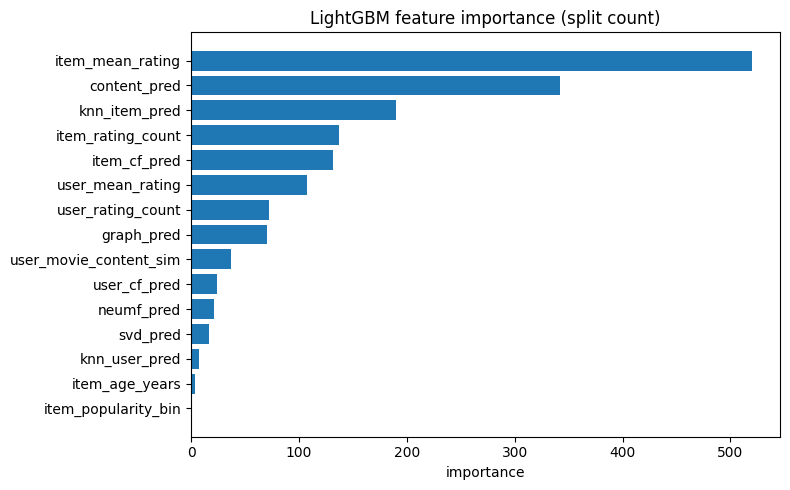

,0
item_mean_rating,520
content_pred,342
knn_item_pred,190
item_rating_count,137
item_cf_pred,132
user_mean_rating,107
user_rating_count,72
graph_pred,70
user_movie_content_sim,37
user_cf_pred,24


In [18]:
fi = pd.Series(gbrt.feature_importances_, index=FEATURE_COLS).sort_values()
plt.figure(figsize=(8, 5))
plt.barh(fi.index, fi.values)
plt.title('LightGBM feature importance (split count)')
plt.xlabel('importance')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_importance.png', dpi=150)
plt.show()
fi.sort_values(ascending=False).head(10)

In [19]:
out = test[['userId', 'movieId']].copy(); out['predicted_rating'] = y_hat
out.to_csv(PREDICTIONS_DIR / 'hybrid_gbrt.csv', index=False)
print(f'Saved final hybrid predictions -> {PREDICTIONS_DIR / "hybrid_gbrt.csv"}')

Saved final hybrid predictions -> /content/gdrive/MyDrive/recsys_artifacts/predictions/hybrid_gbrt.csv
